## EDA AirBnB NYC 2019

In [1]:
import pandas as pd
import numpy as np
import os as os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Load DS from URL

In [2]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv"
df = pd.read_csv(url)

#### Create directory to store data

In [3]:
os.makedirs('./data/raw', exist_ok=True)

#### Save dataset to a CSV file in the specified directory

In [4]:
df.to_csv('./data/raw/AB_NYC_2019.csv', index=False)

#### Confirgurar visualizaciones

In [5]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#### Vista General

In [6]:
df.shape

(48895, 16)

In [7]:
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


### Información General y valores nulos

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [9]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

##### 'name' y 'host_name' tienen valores nulos pero no se usarán en el modelo, así que podemos eliminarlos.
##### 'last_review' y 'reviews_per_month' sí pueden ser relevantes, se imputará o eliminará según análisis.

#### Eliminar columnas no necesarias

In [22]:
df.drop(columns=['name','host_name', 'id', 'host_id'], inplace=True, errors='ignore')
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,38696.0,40.728113,0.055032,40.50641,40.688617,40.721635,40.76299,40.91306
longitude,38696.0,-73.951071,0.046717,-74.24442,-73.982420,-73.954740,-73.93495,-73.71299
price,38696.0,135.225992,105.984459,10.00000,69.000000,100.000000,169.00000,999.00000
minimum_nights,38696.0,5.844403,17.289745,1.00000,1.000000,2.000000,4.00000,1250.00000
number_of_reviews,38696.0,29.346470,48.249822,1.00000,3.000000,9.000000,33.00000,629.00000
reviews_per_month,38696.0,1.375256,1.681915,0.01000,0.190000,0.720000,2.02000,58.50000
calculated_host_listings_count,38696.0,5.173687,26.344427,1.00000,1.000000,1.000000,2.00000,327.00000
availability_365,38696.0,114.506822,129.349758,0.00000,0.000000,55.000000,228.00000,365.00000


> name, host_id, id y host_name no son útiles para el modelo y solo agregan ruido/noise.

### Eliminación de valores nulos restantes

In [23]:
df.dropna(inplace=True)

> Eliminamos registros incompletos para asegurar calidad en el análisis y modelado.


#### Analizar y limpiar outliers en el precio

In [24]:
df['price'].describe()

count    38696.000000
mean       135.225992
std        105.984459
min         10.000000
25%         69.000000
50%        100.000000
75%        169.000000
max        999.000000
Name: price, dtype: float64

### Visualización del precio

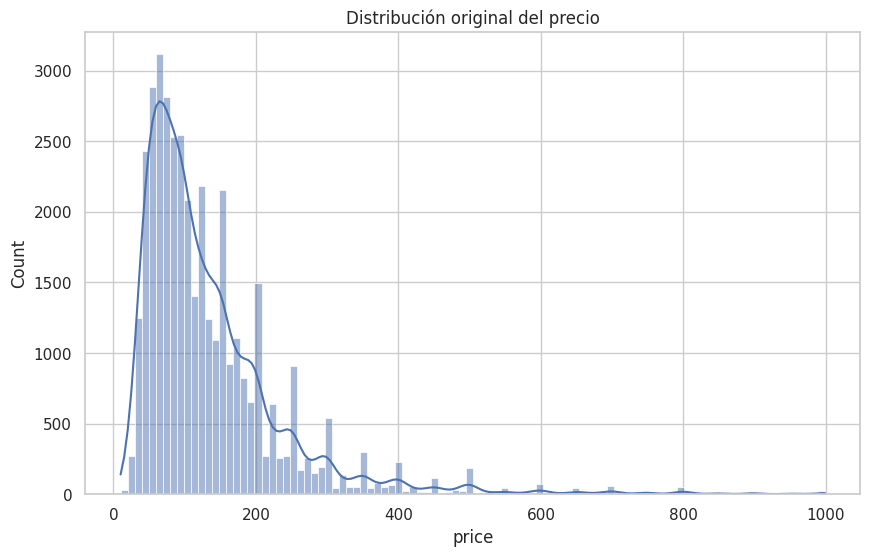

In [25]:

sns.histplot(df['price'], bins=100, kde=True)
plt.title("Distribución original del precio")
plt.show()


### Remover outliers extremos

> Eliminamos precios 0 (inválidos) y > 1000 (extremos)

In [26]:

df = df[df['price'] > 0]
df = df[df['price'] < 1000]

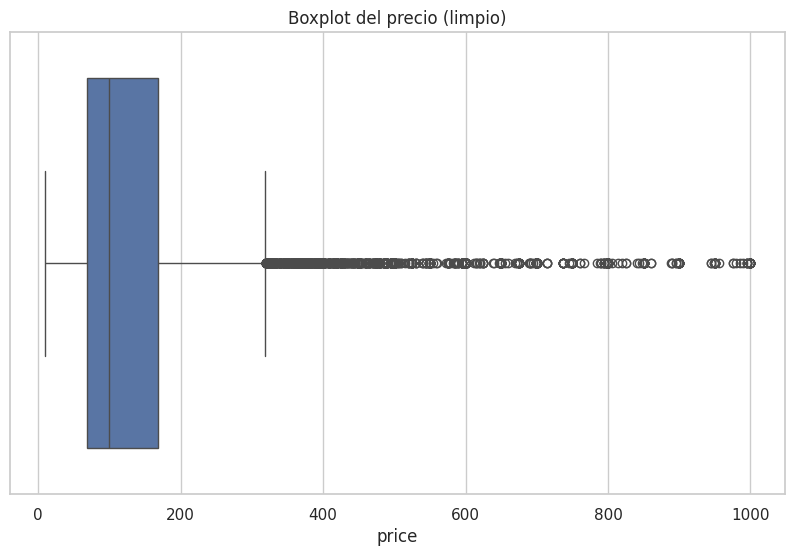

In [27]:
sns.boxplot(x=df['price'])
plt.title("Boxplot del precio (limpio)")
plt.show()


### Análisis por variables categóricas - Por tipo de habitación

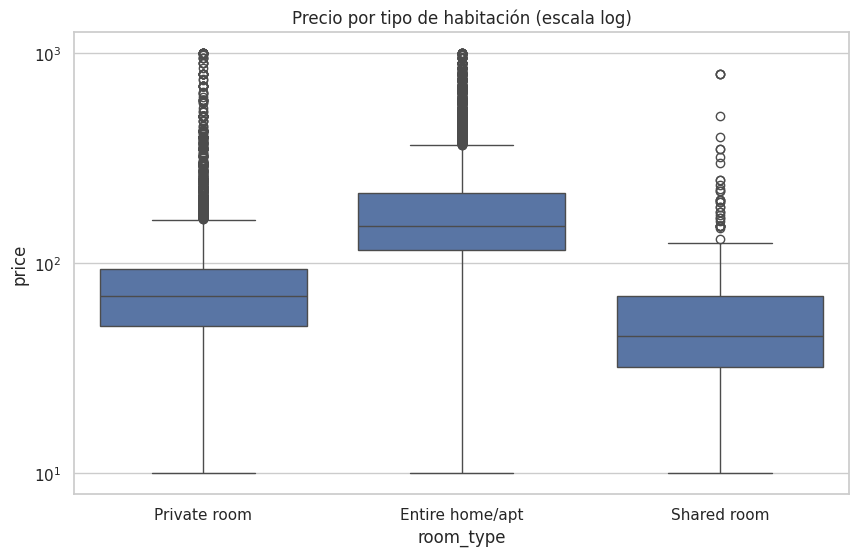

In [28]:

sns.boxplot(data=df, x='room_type', y='price')
plt.yscale('log')
plt.title("Precio por tipo de habitación (escala log)")
plt.show()


> Conclusión: los alojamientos "Entire home/apt" tienen mayores precios en promedio.

### Análisis espacial

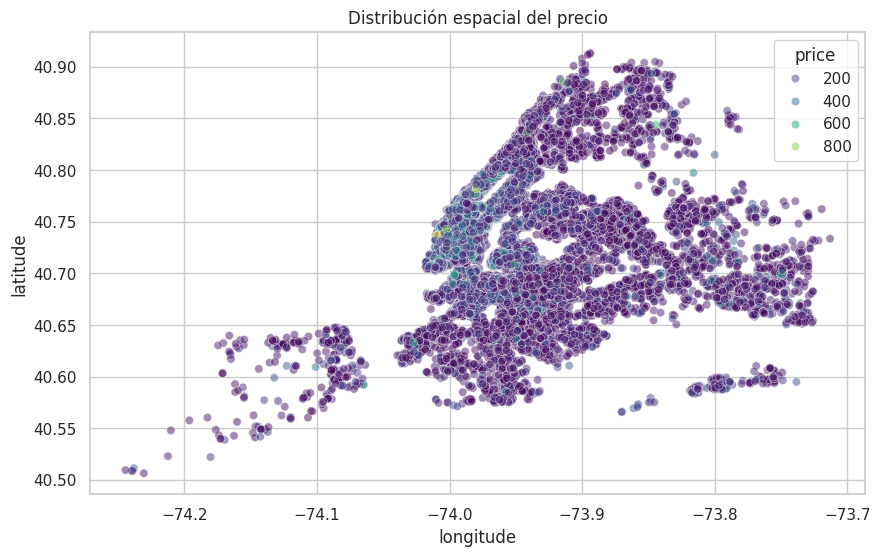

In [29]:

sns.scatterplot(data=df, x='longitude', y='latitude', hue='price', palette='viridis', alpha=0.5)
plt.title("Distribución espacial del precio")
plt.show()

> Los precios más altos se concentran en Manhattan.

### Análisis de correlación

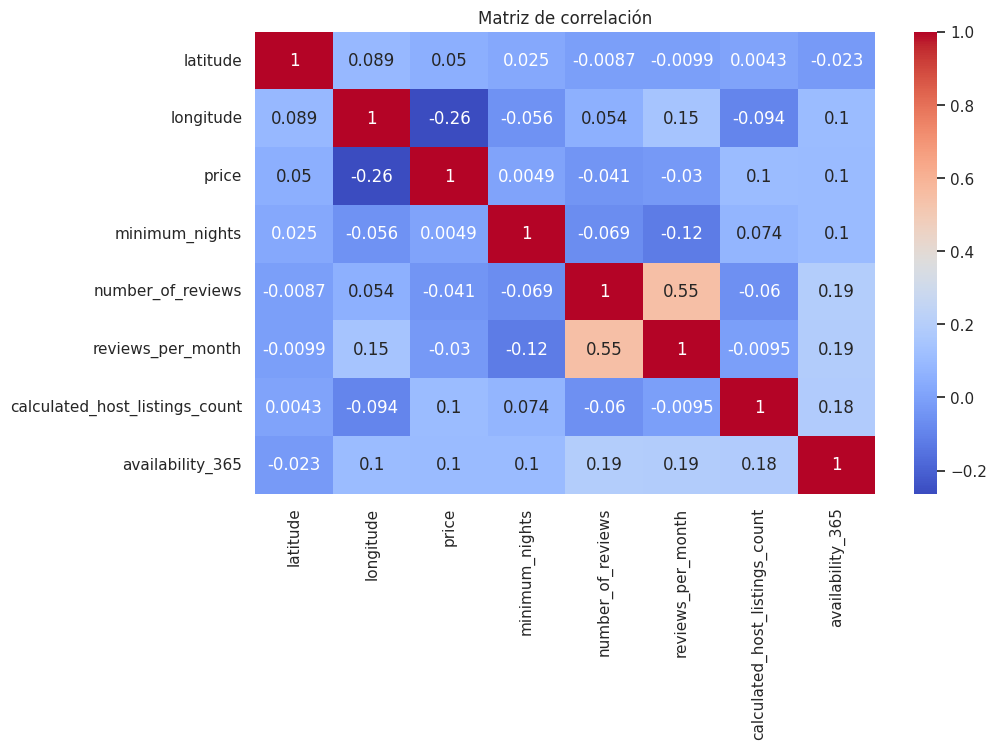

In [30]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

## Modelado

#### Codificación de variables categóricas

In [31]:
df_encoded = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'], drop_first=True)

#### Separación de variables predictoras y target

In [39]:
df_encoded = pd.get_dummies(df, columns=['neighbourhood', 'neighbourhood_group', 'room_type'], drop_first=True)  # 'last_review' es fecha, no útil sin procesamiento
x = df_encoded.drop(columns=['price'])
x = x.select_dtypes(include=[np.number])  # Selecciona solo columnas numéricas
y = df_encoded['price']

#### Division en entrenamiento y prueba

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [42]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predicción y evaluación

In [43]:
y_pred = model.predict(x_test)
print("\nEvaluación del modelo:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))



Evaluación del modelo:
MAE: 66.39564134853417
RMSE: 99.83720020911369
R2 Score: 0.09341002235046114


#### Conclusiones:

> Se eliminaron columnas irrelevantes para reducir ruido.

> Se limpiaron valores nulos y outliers para tener datos más representativos.

> Se analizó la distribución del precio y su relación con ubicación y tipo de habitación.

> Se construyó un modelo de regresión lineal con métricas razonables.

> El modelo puede ser mejorado usando técnicas avanzadas (árboles, random forest, XGBoost, etc.)

> El EDA permitió comprender el negocio (Airbnb NYC), descubrir patrones y preparar datos limpios para modelado.